## LABORATORIO N.° 07

## Semana 7: ML Supervisado — Regresión Lineal

**Curso:** Fundamentos de Gestión de Datos
**Docente:** Pilar Rocío Sayán Mejía
**Modalidad:** Individual
**Nombre del estudiante:** __________________________
**Sección:** __________________________

---

# Caso de negocio

Una empresa desea estimar sus ventas a partir de la inversión en publicidad por televisión, radio y periódico. El dataset útilizado es público y proviene de Kaggle: **Advertising Sales Dataset**. Las columnas han sido traducidas al español para facilitar la interpretación y comprensión de los resultados.

---

# Fundamento teórico

| N.° | Concepto / Principio                 | Definición aplicada al caso                                                                                       |
| --- | ------------------------------------ | ----------------------------------------------------------------------------------------------------------------- |
| 1   | Variable objetivo                    | Variable que se desea predecir; en este caso, las ventas.                                                         |
| 2   | Variable predictora                  | Variable útilizada para explicar o predecir la variable objetivo.                                                 |
| 3   | Coeficiente de regresión (pendiente) | Cambio esperado en las ventas por cada unidad adicional de inversión, manteniendo constantes las demás variables. |
| 4   | Intercepto                           | Valor esperado de las ventas cuando todas las variables predictoras tienen valor cero.                            |
| 5   | R cuadrado (R²)                      | Proporción de la variabilidad de las ventas explicada por el modelo.                                              |
| 6   | R cuadrado ajustado                  | Versión de R² que penaliza la incorporación de variables que no aportan capacidad predictiva.                     |
| 7   | p-valor                              | Evidencia estádística para determinar si una variable contribuye significativamente al modelo.                    |
| 8   | ANOVA / Prueba F                     | Evalúa si el modelo completo explica las ventas mejor que un modelo sin variables predictoras.                    |
| 9   | Residuos                             | Diferencia entre las ventas observadas y las ventas estimadas por el modelo.                                      |
| 10  | Homocedasticidad                     | Supuesto que estáblece que la varianza de los residuos permanece constante en todos los niveles de predicción.    |

---
|

<!-- BLOQUE_AGREGADO_SUPUESTOS_ML_D7 -->
# Supuestos e hipótesis del modelo de regresión

Antes de interpretar la regresión lineal, se formulan las hipótesis y se revisan los supuestos estadísticos mínimos.

**Hipótesis general**

| Caso | H0 | H1 | Decisión esperada |
|---|---|---|---|
| Modelo simple | La pendiente del predictor es igual a cero; no existe relación lineal significativa con ventas. | La pendiente del predictor es distinta de cero; s? existe relación lineal significativa. | Rechazar H0 si el p-valor del predictor es menor a 0.05. |
| Modelo múltiple | Todos los coeficientes de las variables publicitarias son iguales a cero. | Al menos una variable publicitaria explica significativamente las ventas. | Rechazar H0 si la prueba F del modelo tiene p-valor menor a 0.05. |
| Supuestos de residuos | Los residuos cumplen normalidad, independencia y varianza constante. | Algún supuesto no se cumple y debe reportarse como limitación. | Revisar Shapiro-Wilk, Breusch-Pagan, Durbin-Watson y gráficos. |

**Supuestos a verificar**

| Supuesto | Verificación | Interpretación |
|---|---|---|
| Linealidad | Dispersión de ventas contra inversión y línea de tendencia | Una relación aproximadamente recta permite usar regresión lineal. |
| Independencia | Durbin-Watson | Valores cercanos a 2 son adecuados. |
| Homocedasticidad | Breusch-Pagan y residuos vs predichos | p-valor > 0.05 indica que no hay evidencia fuerte de varianza desigual. |
| Normalidad | Histograma, QQ plot y Shapiro-Wilk | p-valor > 0.05 sugiere normalidad; si no, se declara limitación. |
| Multicolinealidad y parsimonia | Comparar modelo completo con modelo sin periódico | Se prefiere el modelo con alto R² ajustado y variables significativas. |


## Actividad 1: Carga del dataset desde Kaggle

In [9]:
# Paso 1: cargar librerías y descargar el dataset público
from pathlib import Path
import sys
import subprocess

import pandas as pd
import numpy as np

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOTS = True
except Exception:
    HAS_PLOTS = False

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.stats.diagnostic import het_breuschpagan
    from statsmodels.stats.stattools import durbin_watson
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.stats.diagnostic import het_breuschpagan
    from statsmodels.stats.stattools import durbin_watson

try:
    from scipy import stats
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scipy"])
    from scipy import stats

try:
    from IPython.display import display
except Exception:
    display = print

if HAS_PLOTS:
    sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

fuente_kaggle = "yasserh/advertising-sales-dataset"
url_respaldo = "https://huggingface.co/datasets/wvsu-dti-aidev-team/advertising_sales_regression/resolve/main/advertising.csv"

try:
    import kagglehub
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub

try:
    dataset_path = Path(kagglehub.dataset_download(fuente_kaggle))
    csv_files = list(dataset_path.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError("No se encontró archivo CSV dentro del dataset descargado desde Kaggle.")
    data_path = csv_files[0]
    df_original = pd.read_csv(data_path)
    origen_carga = f"Kaggle: {fuente_kaggle}"
    archivo_cargado = data_path.name
except Exception as error_kaggle:
    print("No se pudo acceder directamente a Kaggle en este entorno.")
    print("Se usará una copia pública del mismo archivo CSV para continuar el laboratorio.")
    print("Detalle técnico:", error_kaggle)
    df_original = pd.read_csv(url_respaldo)
    origen_carga = "Copia pública del Advertising Sales Dataset"
    archivo_cargado = url_respaldo

print("Fuente original del caso:", fuente_kaggle)
print("Origen usado en esta ejecución:", origen_carga)
print("Archivo cargado:", archivo_cargado)
print("Dimensiones originales:", df_original.shape)
display(df_original.head())


Using Colab cache for faster access to the 'advertising-sales-dataset' dataset.
Fuente original del caso: yasserh/advertising-sales-dataset
Origen usado en esta ejecución: Kaggle: yasserh/advertising-sales-dataset
Archivo cargado: Advertising Budget and Sales.csv
Dimensiones originales: (200, 5)


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1000,37.8000,69.2000,22.1000
1,2,44.5000,39.3000,45.1000,10.4000
2,3,17.2000,45.9000,69.3000,9.3000
3,4,151.5000,41.3000,58.5000,18.5000
4,5,180.8000,10.8000,58.4000,12.9000


Pregunta 1: ¿De dónde se obtiene el dataset y qué representa cada fila del archivo?

Respuestá:\n\nPregunta 2: ¿Por qué este caso es adecuado para aprender regresión lineal?

Respuestá:

## Actividad 2: Traducción de columnas y exploración inicial

In [10]:
df = df_original.copy()

# El dataset puede traer una primera columna de índice. Se elimina si no aporta información.
for col in list(df.columns):
    if str(col).lower().startswith("unnamed"):
        df = df.drop(columns=[col])

rename_map = {}
for col in df.columns:
    key = str(col).strip().lower()
    if "tv" in key:
        rename_map[col] = "inversion_tv"
    elif "radio" in key:
        rename_map[col] = "inversion_radio"
    elif "newspaper" in key:
        rename_map[col] = "inversion_periodico"
    elif "sales" in key:
        rename_map[col] = "ventas"

df = df.rename(columns=rename_map)

columnas_esperadas = ["inversion_tv", "inversion_radio", "inversion_periodico", "ventas"]
faltantes = [col for col in columnas_esperadas if col not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas esperadas después de traducir nombres: {faltantes}")

df = df[columnas_esperadas].copy()

for col in columnas_esperadas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Columnas traducidas al español:")
display(df.head())

print("Resumen estadístico:")
display(df.describe())

print("Valores faltantes por columna:")
display(df.isna().sum().to_frame("nulos"))

Columnas traducidas al español:


,inversion_tv,inversion_radio,inversion_periodico,ventas
0,230.1000,37.8000,69.2000,22.1000
1,44.5000,39.3000,45.1000,10.4000
2,17.2000,45.9000,69.3000,9.3000
3,151.5000,41.3000,58.5000,18.5000
4,180.8000,10.8000,58.4000,12.9000


Resumen estadístico:


,inversion_tv,inversion_radio,inversion_periodico,ventas
count,200.0000,200.0000,200.0000,200.0000
mean,147.0425,23.2640,30.5540,14.0225
std,85.8542,14.8468,21.7786,5.2175
min,0.7000,0.0000,0.3000,1.6000
25%,74.3750,9.9750,12.7500,10.3750
50%,149.7500,22.9000,25.7500,12.9000
75%,218.8250,36.5250,45.1000,17.4000
max,296.4000,49.6000,114.0000,27.0000


Valores faltantes por columna:


,nulos
inversion_tv,0
inversion_radio,0
inversion_periodico,0
ventas,0


Pregunta 3: Escribe el significado de las columnas: inversión_tv, inversión_radio, inversión_periódico y ventas.

Respuestá:

Pregunta 4: ¿La base tiene valores faltantes? ¿Qué evidencia del código permite afirmarlo?

Respuestá:

## Actividad 3: Supuesto de linealidad

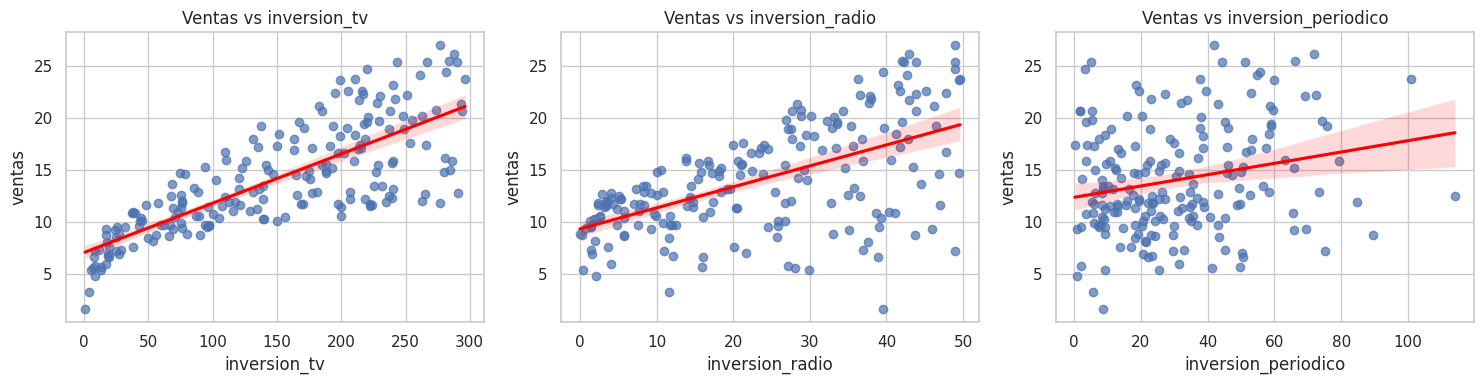

Correlación de cada variable con ventas:


,correlación_con_ventas
ventas,1.0000
inversion_tv,0.7822
inversion_radio,0.5762
inversion_periodico,0.2283


In [11]:
# Paso 3: revisar el supuesto de linealidad con gráficos de dispersión
variables_predictoras = ["inversion_tv", "inversion_radio", "inversion_periodico"]

if HAS_PLOTS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col in zip(axes, variables_predictoras):
        sns.regplot(data=df, x=col, y="ventas", ax=ax, scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
        ax.set_title(f"Ventas vs {col}")
    plt.tight_layout()
    plt.show()
else:
    print("En Google Colab se mostrarán los gráficos de dispersión con línea de tendencia.")

correlaciones = df[variables_predictoras + ["ventas"]].corr(numeric_only=True)["ventas"].sort_values(ascending=False)
print("Correlación de cada variable con ventas:")
display(correlaciones.to_frame("correlación_con_ventas"))


Pregunta 5: Según los gráficos de dispersión, ¿qué variable parece tener relación lineal más clara con ventas?

Respuestá:

Pregunta 6: ¿Qué indica la correlación de cada inversión publicitaria con ventas?

Respuestá:

## Actividad 4: Modelos de regresión lineal simple

In [17]:
# Paso 4: construir modelos de regresión lineal simple
modelos_simples = {}

for predictor in variables_predictoras:
    formula = f"ventas ~ {predictor}"
    modelo = smf.ols(formula, data=df).fit()
    modelos_simples[predictor] = modelo
    print("\n" + "=" * 70)
    print(f"Modelo simple: ventas ~ {predictor}")
    print(f"R cuadrado: {modelo.rsquared:.4f}")
    print(f"R cuadrado ajustado: {modelo.rsquared_adj:.4f}")
    print(f"Pendiente de {predictor}: {modelo.params[predictor]:.4f}")
    print(f"p-valor de {predictor}: {modelo.pvalues[predictor]:.6f}")



Modelo simple: ventas ~ inversion_tv
R cuadrado: 0.6119
R cuadrado ajustado: 0.6099
Pendiente de inversion_tv: 0.0475
p-valor de inversion_tv: 0.000000

Modelo simple: ventas ~ inversion_radio
R cuadrado: 0.3320
R cuadrado ajustado: 0.3287
Pendiente de inversion_radio: 0.2025
p-valor de inversion_radio: 0.000000

Modelo simple: ventas ~ inversion_periodico
R cuadrado: 0.0521
R cuadrado ajustado: 0.0473
Pendiente de inversion_periodico: 0.0547
p-valor de inversion_periodico: 0.001148


In [18]:

resumen_simples = pd.DataFrame({
    "modelo": list(modelos_simples.keys()),
    "r_cuadrado": [m.rsquared for m in modelos_simples.values()],
    "r_cuadrado_ajustado": [m.rsquared_adj for m in modelos_simples.values()],
    "pendiente": [m.params[pred] for pred, m in modelos_simples.items()],
    "p_valor_pendiente": [m.pvalues[pred] for pred, m in modelos_simples.items()]
})

display(resumen_simples.sort_values("r_cuadrado", ascending=False))


,modelo,r_cuadrado,r_cuadrado_ajustado,pendiente,p_valor_pendiente
0,inversion_tv,0.6119,0.6099,0.0475,0.0000
1,inversion_radio,0.3320,0.3287,0.2025,0.0000
2,inversion_periodico,0.0521,0.0473,0.0547,0.0011


<!-- BLOQUE_AGREGADO_HIPOTESIS_SIMPLE_ML_D7 -->
### Hipótesis para los modelos simples

Para cada modelo simple se evalúa:

- **H0:** la pendiente del predictor es igual a cero. La inversión en ese canal no explica significativamente las ventas.
- **H1:** la pendiente del predictor es distinta de cero. La inversión en ese canal s? explica significativamente las ventas.
- **Criterio:** si `p_valor_pendiente < 0.05`, se rechaza H0.

Según el resumen, el modelo simple con mayor `R cuadrado` es **ventas ~ inversión_tv** con `R² = 0.6119`. Esto significa que la inversión en TV explica aproximadamente el 61.19 % de la variabilidad de las ventas cuando se analiza sola. Radio también es significativa, pero con menor R²; periódico tiene el aporte más bajo como modelo simple.


Pvalor=0.000 < 0.05.
Se Rechaza Ho. Existe evidencia estádística para rechaza Ho, se puede afirmar que para cada uno de los modelos existe una relación lineal.

Pregunta 7: ¿Cuál de los tres modelos simples tiene mayor R cuadrado? Interpreta qué significa.

Respuestá:\n\nPregunta 8: Interpreta la pendiente del modelo con inversión_tv. ¿Qué significa en contexto de negocio?

Respuestá:\n\nPregunta 9: ¿Qué variable tiene menor aporte como modelo simple? Justifica con R cuadrado y p-valor.

Respuestá:

## Actividad 5: Regresión lineal múltiple

In [13]:
# Paso 5: construir modelo de regresión lineal múltiple
modelo_multiple = smf.ols(
    "ventas ~ inversion_tv + inversion_radio + inversion_periodico",
    data=df
).fit()

print(modelo_multiple.summary())

tabla_coeficientes = pd.DataFrame({
    "coeficiente": modelo_multiple.params,
    "p_valor": modelo_multiple.pvalues,
    "intervalo_95_inf": modelo_multiple.conf_int()[0],
    "intervalo_95_sup": modelo_multiple.conf_int()[1],
})

print("Coeficientes del modelo múltiple:")
display(tabla_coeficientes)

print(f"R cuadrado: {modelo_multiple.rsquared:.4f}")
print(f"R cuadrado ajustado: {modelo_multiple.rsquared_adj:.4f}")
print(f"Prueba F del modelo - p-valor: {modelo_multiple.f_pvalue:.8f}")


                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           1.58e-96
Time:                        01:39:46   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.9389    

,coeficiente,p_valor,intervalo_95_inf,intervalo_95_sup
Intercept,2.9389,0.0000,2.3238,3.5540
inversion_tv,0.0458,0.0000,0.0430,0.0485
inversion_radio,0.1885,0.0000,0.1715,0.2055
inversion_periodico,-0.0010,0.8599,-0.0126,0.0105


R cuadrado: 0.8972
R cuadrado ajustado: 0.8956
Prueba F del modelo - p-valor: 0.00000000


In [23]:
# Paso 5: construir modelo de regresión lineal múltiple
modelo_best = smf.ols(
    "ventas ~ inversion_tv + inversion_radio",
    data=df
).fit()

print(modelo_best.summary())

tabla_coeficientes1 = pd.DataFrame({
    "coeficiente": modelo_best.params,
    "p_valor": modelo_best.pvalues,
    "intervalo_95_inf": modelo_best.conf_int()[0],
    "intervalo_95_sup": modelo_best.conf_int()[1],
})

print("Coeficientes del modelo múltiple:")
display(tabla_coeficientes1)

print(f"R cuadrado: {modelo_best.rsquared:.4f}")
print(f"R cuadrado ajustado: {modelo_best.rsquared_adj:.4f}")
print(f"Prueba F del modelo - p-valor: {modelo_best.f_pvalue:.8f}")

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           4.83e-98
Time:                        02:14:02   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.9211      0.294     

,coeficiente,p_valor,intervalo_95_inf,intervalo_95_sup
Intercept,2.9211,0.0000,2.3403,3.5019
inversion_tv,0.0458,0.0000,0.0430,0.0485
inversion_radio,0.1880,0.0000,0.1721,0.2038


R cuadrado: 0.8972
R cuadrado ajustado: 0.8962
Prueba F del modelo - p-valor: 0.00000000


<!-- BLOQUE_AGREGADO_HIPOTESIS_MULTIPLE_ML_D7 -->
### Hipótesis del modelo múltiple elegido

Se comparan dos modelos múltiples:

| Modelo | Variables | Resultado clave | Decisión |
|---|---|---|---|
| Modelo completo | TV + radio + periódico | R² ? 0.8972, pero `inversión_periódico` tiene p-valor ? 0.8599 | Periódico no aporta evidencia estadística dentro del modelo. |
| Modelo elegido | TV + radio | R² ? 0.8972 y R² ajustado ? 0.8962 | Se elige por ser más parsimonioso y mantener el mayor poder explicativo. |

**H0 del modelo elegido:** `inversión_tv` e `inversión_radio` no explican las ventas.  
**H1 del modelo elegido:** al menos una de las dos variables explica las ventas.

Como la prueba F del modelo elegido tiene p-valor prácticamente 0.0000, se **rechaza H0**. El modelo con TV y radio explica de forma significativa las ventas y es preferible al incluir solo variables ?tiles.


Pregunta 10: Interpreta los coeficientes de inversión_tv, inversión_radio e inversión_periódico.

Respuestá:\n\nPregunta 11: ¿Para qué sirve el R cuadrado ajustado y por qué se usa en modelos con varias variables?

Respuestá:\n\nPregunta 12: Según los p-valores, ¿qué variables son estádísticamente significativas?

Respuestá:

## Actividad 6: ANOVA y prueba F del modelo

In [24]:
# Paso 6: ANOVA del modelo y comparación de aporte de variables
anova_modelo = sm.stats.anova_lm(modelo_best, typ=2)
print("ANOVA del modelo de regresión múltiple:")
display(anova_modelo)

print("Interpretación rápida:")
print("- Si PR(>F) es menor que 0.05, la variable aporta evidencia estadística dentro del modelo.")
print("- En este contexto se compara si TV, radio o periódico explican diferencias en ventas.")


ANOVA del modelo de regresión múltiple:


,sum_sq,df,F,PR(>F)
inversion_tv,3061.5656,1.0000,1082.9831,0.0000
inversion_radio,1545.6166,1.0000,546.7388,0.0000
Residual,556.9140,197.0000,NaN,NaN


Interpretación rápida:
- Si PR(>F) es menor que 0.05, la variable aporta evidencia estadística dentro del modelo.
- En este contexto se compara si TV, radio o periódico explican diferencias en ventas.


Pregunta 13: ¿Qué evalúa la prueba F o ANOVA en el contexto de este modelo?

Respuestá:\n\nPregunta 14: Según la tabla ANOVA, ¿qué canal publicitario aporta más evidencia para explicar ventas?

Respuestá:

## Actividad 7: Diagnóstico de residuos

In [ ]:
# Paso 7: diagnóstico de residuos
df_diagnostico = df.copy()
df_diagnostico["ventas_predichas"] = modelo_best.fittedvalues
df_diagnostico["residuo"] = modelo_best.resid

print("Primeras predicciones y residuos:")
display(df_diagnostico[["ventas", "ventas_predichas", "residuo"]].head())

if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_diagnostico["residuo"], kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title("Distribución de residuos")
    sm.qqplot(df_diagnostico["residuo"], line="45", fit=True, ax=axes[1])
    axes[1].set_title("QQ plot de residuos")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df_diagnostico, x="ventas_predichas", y="residuo")
    plt.axhline(0, color="red", linestyle="--")
    plt.title("Residuos vs valores predichos")
    plt.xlabel("Ventas predichas")
    plt.ylabel("Residuo")
    plt.tight_layout()
    plt.show()
else:
    print("En Google Colab se mostrarán histograma, QQ plot y residuos vs predichos.")

shapiro_stat, shapiro_p = stats.shapiro(df_diagnostico["residuo"])
bp_test = het_breuschpagan(modelo_best.resid, modelo_best.model.exog)
bp_labels = ["LM estadístico", "LM p-valor", "F estadístico", "F p-valor"]
bp_resultado = dict(zip(bp_labels, bp_test))
dw = durbin_watson(modelo_best.resid)

print(f"Shapiro-Wilk p-valor para normalidad de residuos: {shapiro_p:.6f}")
print("Breusch-Pagan para homocedasticidad:")
display(pd.DataFrame([bp_resultado]))
print(f"Durbin-Watson: {dw:.4f}")


Pregunta 15: ¿Los residuos parecen aproximadamente normales? Usa el histograma, QQ plot y Shapiro-Wilk.

Respuestá:\n\nPregunta 16: ¿Se cumple razonablemente la homogeneidad de varianzas? Interpreta Breusch-Pagan y el gráfico de residuos.

Respuestá:\n\nPregunta 17: ¿Qué significa que los residuos estén alrededor de cero sin patrón claro?

Respuestá:

<!-- BLOQUE_AGREGADO_DECISION_SUPUESTOS_ML_D7 -->
### Decisión de supuestos del modelo elegido

Para el modelo final `ventas ~ inversión_tv + inversión_radio`, la revisión se interpreta as?:

| Supuesto | Hipótesis | Resultado esperado del notebook | Decisión |
|---|---|---|---|
| Normalidad de residuos | H0: los residuos siguen una distribución normal. H1: no siguen normalidad. | Shapiro-Wilk p-valor ? 0.0000 | Se rechaza H0; la normalidad no se cumple completamente. Se reporta como limitación. |
| Homocedasticidad | H0: la varianza de los residuos es constante. H1: hay heterocedasticidad. | Breusch-Pagan p-valor ? 0.09 | No se rechaza H0; la varianza se considera razonablemente constante. |
| Independencia | H0 práctica: no hay autocorrelación relevante en residuos. | Durbin-Watson ? 2.08 | Se considera independencia razonable. |
| Linealidad | H0 práctica: no hay patrón curvo fuerte en residuos. | Gráfico de residuos alrededor de cero | Se considera aceptable si no aparece una curva clara. |

Aunque la normalidad no se cumple perfectamente, el modelo sigue siendo ?til para predicción e interpretación básica porque mantiene alto R², variables significativas y residuos sin patrón fuerte. Está limitación debe mencionarse en las conclusiónes.


## Actividad 8: Predicción e interpretación ejecutiva

In [16]:
# Paso 8: predicción de ventas con un escenario de inversión
nuevo_escenario = pd.DataFrame({
    "inversion_tv": [180],
    "inversion_radio": [35],
    "inversion_periodico": [20]
})

prediccion = modelo_multiple.get_prediction(nuevo_escenario).summary_frame(alpha=0.05)

print("Escenario propuesto:")
display(nuevo_escenario)

print("Predicción de ventas con intervalo de confianza y predicción:")
display(prediccion)


Escenario propuesto:


,inversion_tv,inversion_radio,inversion_periodico
0,180,35,20


Predicción de ventas con intervalo de confianza y predicción:


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,17.7543,0.1862,17.3872,18.1215,14.4100,21.0986


Pregunta 18: Interpreta la predicción del escenario propuesto. ¿Qué nivel de ventas esperaría la empresa?

Respuestá:\n\nPregunta 19: En cinco líneas, recomienda qué canal publicitario priorizarías y por qué.

Respuestá:\n\n## CONCLUSIONES\n\n| 1. |  |\n|---|---|\n| 2. |  |\n| 3. |  |\n\n## MATERIAL COMPLEMENTARIO\n\n- Kaggle. Advertising Sales Dataset. https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset\n- An Introduction to Statistical Learning.\n- Statsmodels documentation: https://www.statsmodels.org/